
Характеристики для Нормальное распределения
---------------------------------------------------------------------------
Характеристика                  n=10           n=100          n=1000
---------------------------------------------------------------------------
Выборочное среднее          0.0±0.3        0.0±0.1        0.0±0.0
Медиана                     0.0±0.4       -0.0±0.1        0.0±0.0
ZR                          0.0±0.4        0.0±0.3       -0.0±0.3
ZQ                          0.0±0.3        0.0±0.1        0.0±0.0
Ztr                         0.0±0.3       -0.0±0.1        0.0±0.0
---------------------------------------------------------------------------


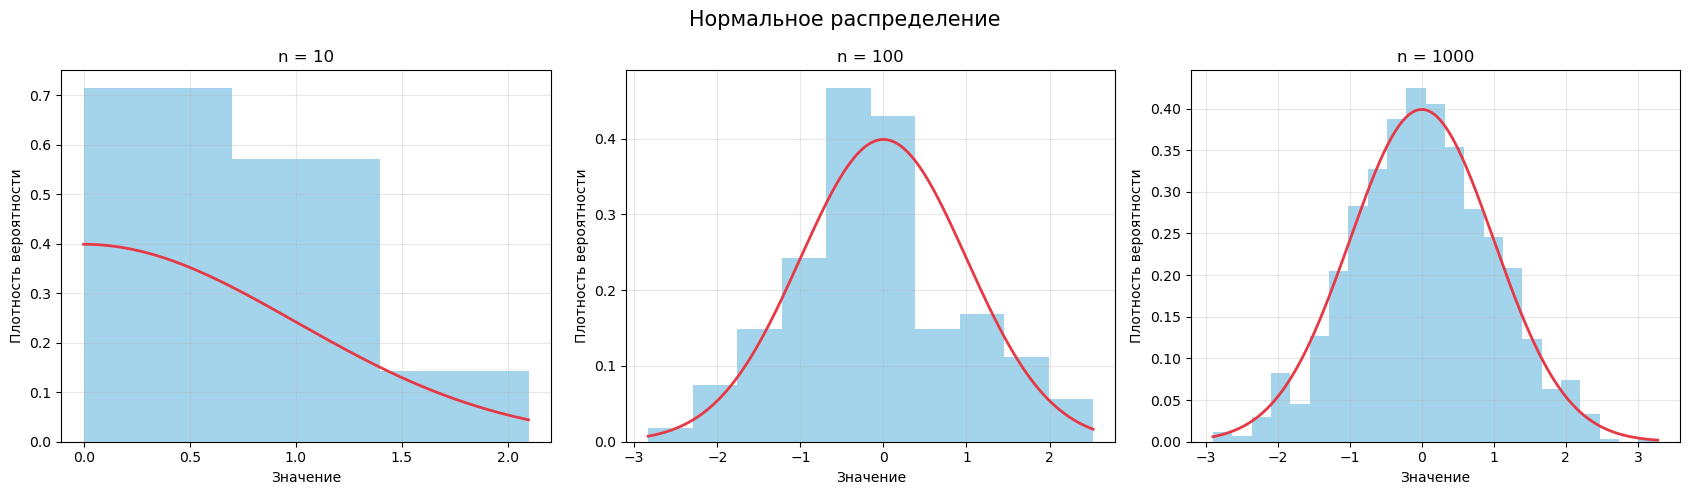


Характеристики для Коши распределения
---------------------------------------------------------------------------
Характеристика                  n=10           n=100          n=1000
---------------------------------------------------------------------------
Выборочное среднее         0.1±17.0   -43.1±1448.1     25.1±959.5
Медиана                     0.0±0.6       -0.0±0.2        0.0±0.1
ZR                        -0.0±83.8-2150.7±72401.912562.4±479725.7
ZQ                          0.0±1.0       -0.0±0.2        0.0±0.1
Ztr                         0.1±1.3       -0.0±0.2        0.0±0.1
---------------------------------------------------------------------------


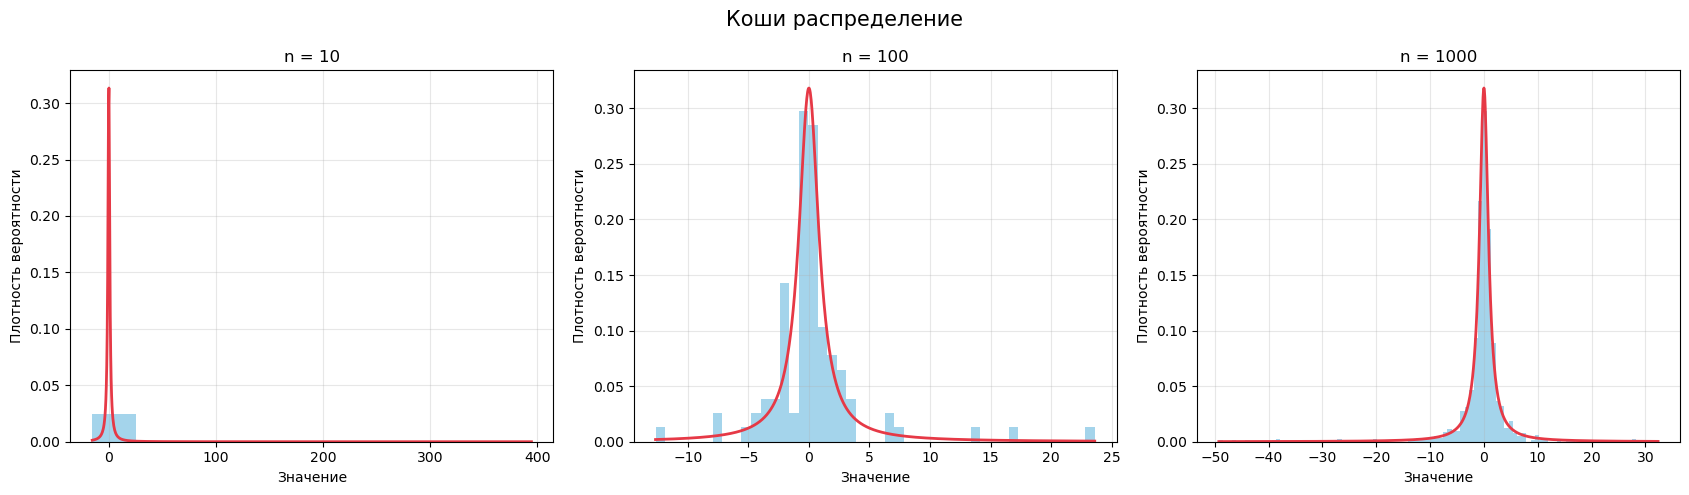


Характеристики для Лапласа распределения
---------------------------------------------------------------------------
Характеристика                  n=10           n=100          n=1000
---------------------------------------------------------------------------
Выборочное среднее         -0.0±0.3        0.0±0.1        0.0±0.0
Медиана                    -0.0±0.3       -0.0±0.1        0.0±0.0
ZR                         -0.0±0.7       -0.0±0.6       -0.0±0.6
ZQ                         -0.0±0.3        0.0±0.1        0.0±0.0
Ztr                        -0.0±0.3        0.0±0.1        0.0±0.0
---------------------------------------------------------------------------


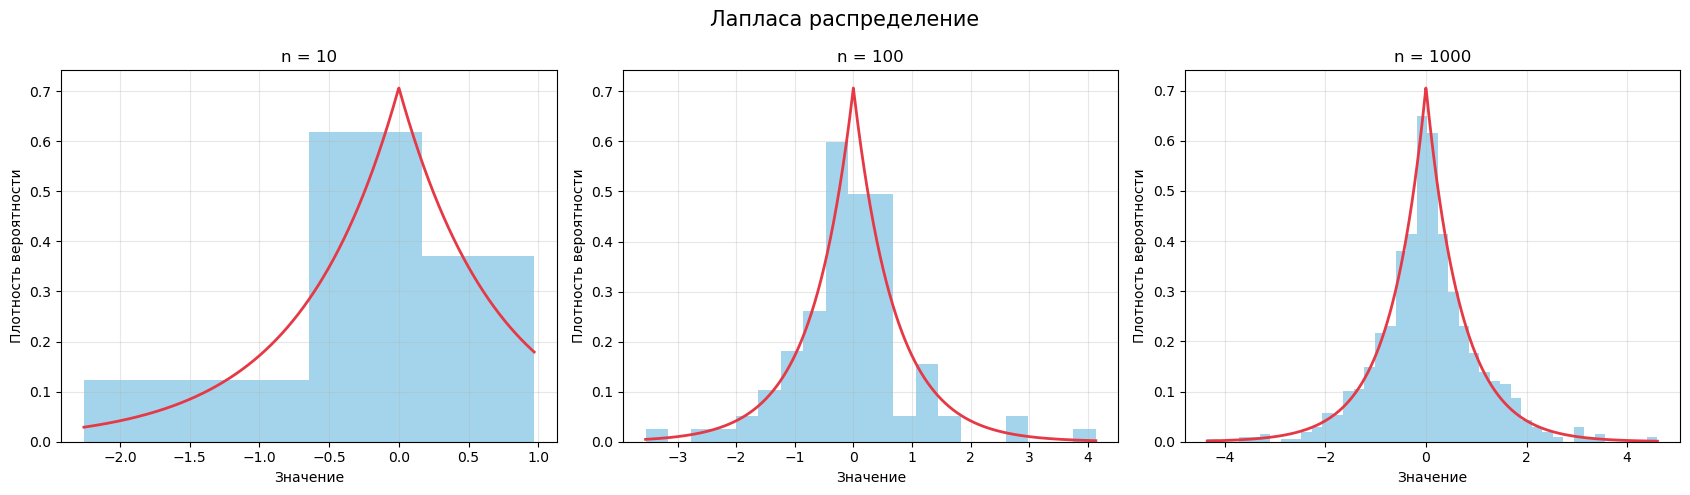


Характеристики для Пуассона распределения
---------------------------------------------------------------------------
Характеристика                  n=10           n=100          n=1000
---------------------------------------------------------------------------
Выборочное среднее         10.0±1.0       10.0±0.3       10.0±0.1
Медиана                     9.9±1.2        9.9±0.4       10.0±0.1
ZR                         10.2±1.4       11.0±1.0       11.7±0.8
ZQ                          9.9±1.0        9.9±0.4       10.0±0.1
Ztr                         9.9±1.0        9.9±0.3        9.9±0.1
---------------------------------------------------------------------------


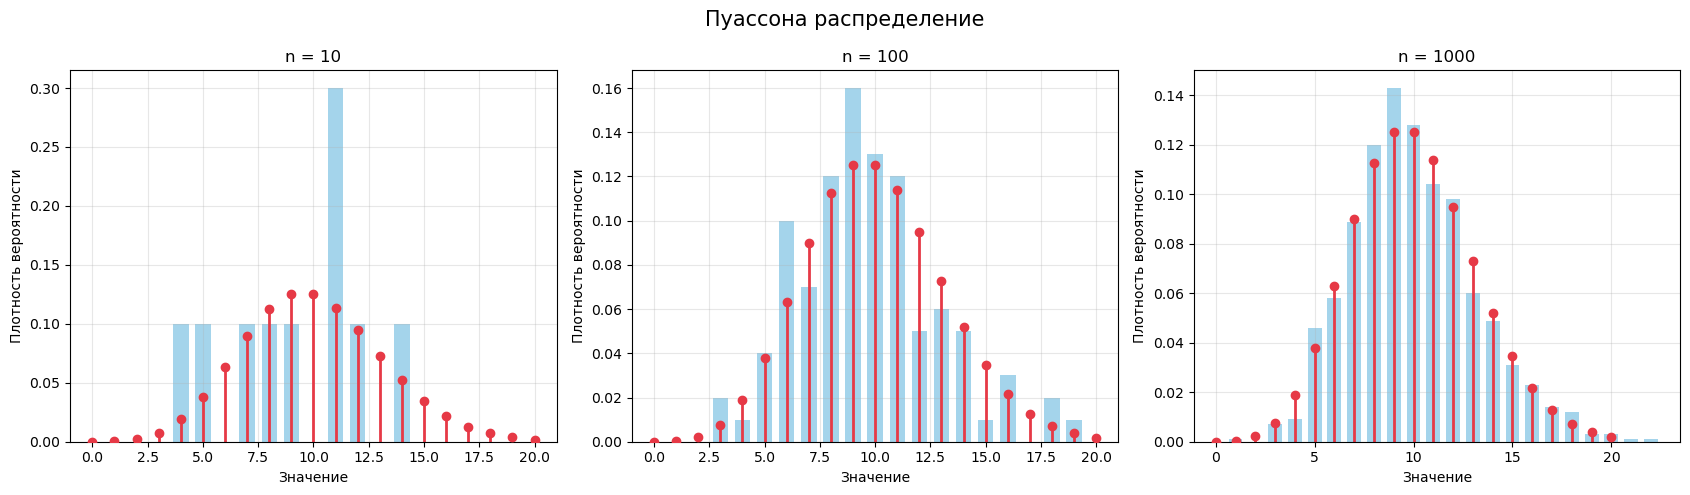


Характеристики для Равномерное распределения
---------------------------------------------------------------------------
Характеристика                  n=10           n=100          n=1000
---------------------------------------------------------------------------
Выборочное среднее          0.0±0.3       -0.0±0.1        0.0±0.0
Медиана                     0.0±0.5       -0.0±0.2        0.0±0.1
ZR                          0.0±0.2       -0.0±0.0       -0.0±0.0
ZQ                          0.0±0.4       -0.0±0.1        0.0±0.0
Ztr                         0.0±0.4       -0.0±0.1        0.0±0.0
---------------------------------------------------------------------------


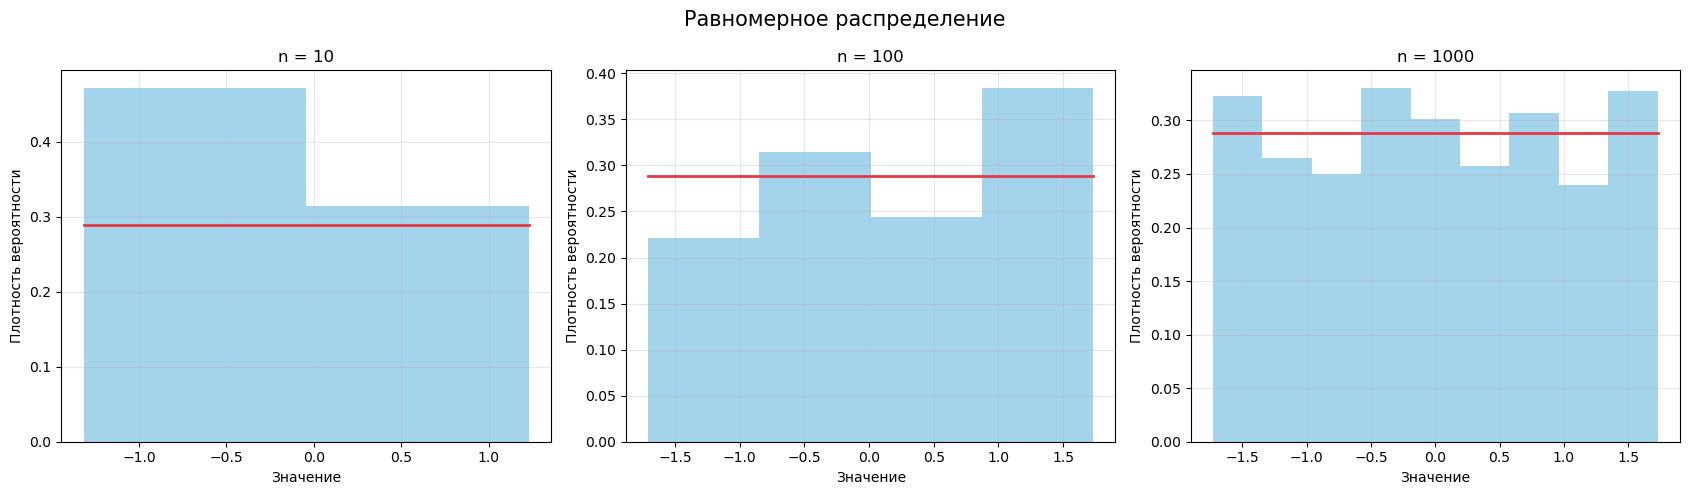

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def choose_bin_count(data):
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    if iqr > 0:
        h = 2 * iqr / (len(data) ** (1 / 3))
        bins = int((data.max() - data.min()) / h)
    else:
        bins = 10

    bins = min(bins, 100, len(np.unique(data)))
    return max(2, bins)


def theoretical_density(dist_name, x):
    if dist_name == "Нормальное":
        return stats.norm.pdf(x, 0, 1)
    if dist_name == "Коши":
        return stats.cauchy.pdf(x, 0, 1)
    if dist_name == "Лапласа":
        return stats.laplace.pdf(x, 0, 1 / np.sqrt(2))
    if dist_name == "Равномерное":
        return stats.uniform.pdf(x, -np.sqrt(3), 2 * np.sqrt(3))


def visible_range(data, dist_name):
    if dist_name == "Коши":
        return np.percentile(data, [1, 99])
    return data.min(), data.max()


def draw_distribution(dist_name, samples, sizes):
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    hist_color = "#8ecae6"
    curve_color = "#e63946"

    for ax, sample, n in zip(axes, samples, sizes):
        x_min, x_max = visible_range(sample, dist_name)
        bins = choose_bin_count(sample)

        if dist_name == "Пуассона":
            values, counts = np.unique(sample, return_counts=True)
            ax.bar(values, counts / len(sample),
                   width=0.7, color=hist_color, alpha=0.8)

            x_t = np.arange(0, 21)
            y_t = stats.poisson.pmf(x_t, 10)
            ax.vlines(x_t, 0, y_t, color=curve_color, linewidth=2)
            ax.scatter(x_t, y_t, color=curve_color, zorder=3)

        else:
            ax.hist(sample, bins=bins, range=(x_min, x_max),
                    density=True, color=hist_color, alpha=0.8)

            x = np.linspace(x_min, x_max, 1000)
            y = theoretical_density(dist_name, x)
            ax.plot(x, y, color=curve_color, linewidth=2)

        ax.set_title(f"n = {n}")
        ax.set_xlabel("Значение")
        ax.set_ylabel("Плотность вероятности")
        ax.grid(alpha=0.3)

    fig.suptitle(f"{dist_name} распределение", fontsize=15)
    plt.tight_layout()
    plt.show()


def sample_statistics(sample):
    n = len(sample)
    trimmed = np.sort(sample)[int(0.1 * n): int(0.9 * n)]

    return {
        "mean": np.mean(sample),
        "median": np.median(sample),
        "zR": (sample.min() + sample.max()) / 2,
        "zQ": np.mean(np.percentile(sample, [25, 75])),
        "ztr": np.mean(trimmed)
    }


def print_statistics(dist_name, results, n):
    print(f"\n{dist_name} распределение (n = {n})")
    print("| Оценка      | Среднее      | Дисперсия    | <x> ± √D |")
    print("|-------------|--------------|--------------|----------|")

    for key, values in results.items():
        m = np.mean(values)
        v = np.var(values, ddof=1)
        print(f"| {key:<11} | {m:>12.6f} | {v:>12.6f} | {m:.1f} ± {np.sqrt(v):.1f} |")


def print_report_table(dist_name, table):
    print(f"\nХарактеристики для {dist_name} распределения")
    print("-" * 75)
    print(f"{'Характеристика':<20} {'n=10':>15} {'n=100':>15} {'n=1000':>15}")
    print("-" * 75)

    for stat_name, values in table.items():
        row = f"{stat_name:<20}"
        for mean_val, var_val in values:
            m = round(mean_val, 1)
            s = round(np.sqrt(var_val), 1)
            row += f"{f'{m}±{s}':>15}"
        print(row)

    print("-" * 75)



def run_experiment():
    rng = np.random.default_rng(5)

    sizes = [10, 100, 1000]
    repeats = 1000

    generators = {
        "Нормальное": lambda n: rng.normal(0, 1, n),
        "Коши": lambda n: rng.standard_cauchy(n),
        "Лапласа": lambda n: rng.laplace(0, 1 / np.sqrt(2), n),
        "Пуассона": lambda n: rng.poisson(10, n),
        "Равномерное": lambda n: rng.uniform(-np.sqrt(3), np.sqrt(3), n)
    }

    for dist_name, gen in generators.items():

        report_table = {
            "Выборочное среднее": [],
            "Медиана": [],
            "ZR": [],
            "ZQ": [],
            "Ztr": []
        }

        for n in sizes:
            collected = {
                "mean": [],
                "median": [],
                "zR": [],
                "zQ": [],
                "ztr": []
            }

            for _ in range(repeats):
                sample = gen(n)
                stats_vals = sample_statistics(sample)
                for key in collected:
                    collected[key].append(stats_vals[key])

            report_table["Выборочное среднее"].append(
                (np.mean(collected["mean"]), np.var(collected["mean"], ddof=1))
            )
            report_table["Медиана"].append(
                (np.mean(collected["median"]), np.var(collected["median"], ddof=1))
            )
            report_table["ZR"].append(
                (np.mean(collected["zR"]), np.var(collected["zR"], ddof=1))
            )
            report_table["ZQ"].append(
                (np.mean(collected["zQ"]), np.var(collected["zQ"], ddof=1))
            )
            report_table["Ztr"].append(
                (np.mean(collected["ztr"]), np.var(collected["ztr"], ddof=1))
            )

        print_report_table(dist_name, report_table)

        samples_for_plot = [gen(n) for n in sizes]
        draw_distribution(dist_name, samples_for_plot, sizes)




if __name__ == "__main__":
    run_experiment()
